In [1]:
import pandas as pd
import os, json

import json, pickle
import random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import csv
import pandas as pd
import time
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt

## Rating score extraction (Human and CLIP)

In [2]:
"""
Extract rating scores from individual result files from deployed folder and compile them into a single CSV file.
"""
import os
from datetime import datetime
import pandas as pd

formal_dir = "/opt/jinhanz/results/2509_concreteness/deployed/deploy_0818/formal/" # TODO: setup config info file
df_human = pd.DataFrame()

output_dir = "../../results/251104_lextale60/human/ratings"

for b in range(1,5):
    block_dir = os.path.join(formal_dir, f"Block{b}_deploy", "results")
    
    for subject_dir in os.listdir(block_dir):
        subject_path = os.path.join(block_dir, subject_dir)
        if not os.path.isdir(subject_path):
            continue
        
        subject_res_path = os.path.join(subject_path, "RESULTS_FILE.txt")

        if os.path.exists(subject_res_path):
            df = pd.read_csv(subject_res_path, sep='\s+')
            # TODO: assert subject number matches, assert block number matches
            # TODO: readin block order information
            df_human = pd.concat([df_human, df], ignore_index=True)
df_human['answer'] = df_human['answer'] / 100
df_human['image_id'] = df_human['imagename'].apply(lambda x: f"val2014/{'_'.join(x.split('_')[2:])}")
df_human['match'] = df_human['imagename'].apply(lambda x: x.split('_')[0])
df_human['condition'] = df_human['imagename'].apply(lambda x: x.split('_')[1])
df_human.to_csv(os.path.join(output_dir, f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_rating_scores.csv"), index=False)

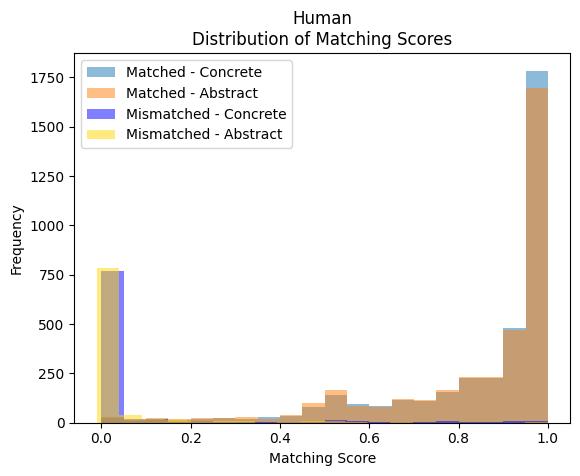

In [3]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='blue', alpha=0.5, label='Mismatched - Concrete')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='gold', alpha=0.5, label='Mismatched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

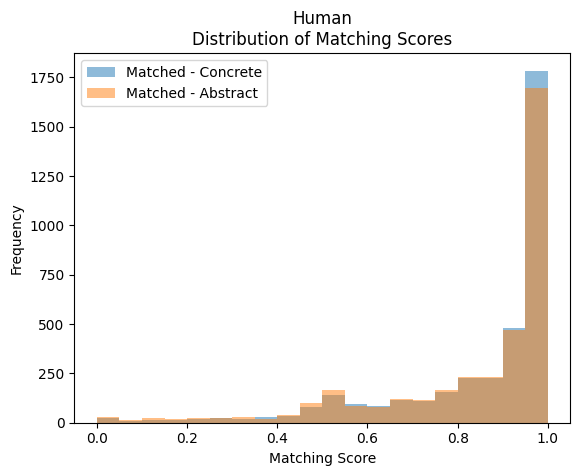

In [5]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

## Human Model Alignment

In [6]:
experiment = '20250723_193742'

df_clip = pd.read_csv(f"../../stimuli/250602-250723_stimuli_average/{experiment}/captions_and_attributes.csv")
df_clip = df_clip.sort_values(by='image_id')

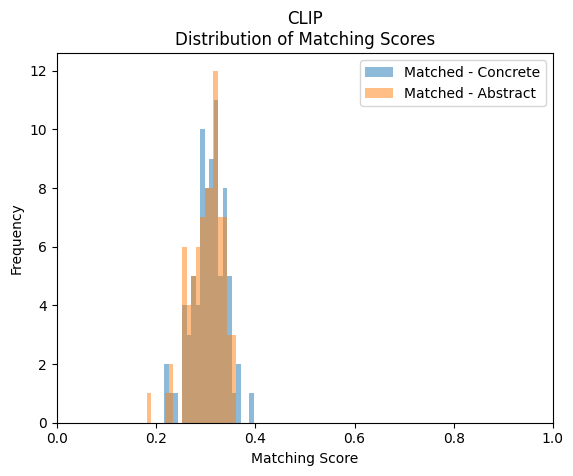

In [7]:
plt.hist(df_clip['con_matching_score'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_clip['abs_matching_score'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.title('CLIP\nDistribution of Matching Scores')
plt.legend()
plt.show()

### Rating Normalization

In [8]:
df_human = df_human[df_human['match'] == 'matched']
df_human['answer_normalized'] = df_human.groupby('subject_no')['answer'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

In [9]:
min_score = min(df_clip['abs_matching_score'].min(), df_clip['con_matching_score'].min())
max_score = max(df_clip['abs_matching_score'].max(), df_clip['con_matching_score'].max())

df_clip['abs_matching_score_normalized'] = (df_clip['abs_matching_score'] - min_score) / (max_score - min_score)
df_clip['con_matching_score_normalized'] = (df_clip['con_matching_score'] - min_score) / (max_score - min_score)

### By-subject

In [ ]:
subjs = df_human['subject_no'].unique()
subj_num = len(subjs)

alignment_con = np.zeros(subj_num)
alignment_abs = np.zeros(subj_num)

for s, subj in enumerate(subjs):
    df_subj = df_human[(df_human['match'] == 'matched') & (df_human['subject_no']==subj)]
    df_subj_con = df_subj[df_subj['condition'] == 'con'].sort_values(by='image_id')
    df_subj_abs = df_subj[df_subj['condition'] == 'abs'].sort_values(by='image_id')

    assert df_subj_con['image_id'].tolist() == df_clip['image_id'].tolist()
    assert df_subj_abs['image_id'].tolist() == df_clip['image_id'].tolist()

    alignment_con[s] = np.corrcoef(df_subj_con['answer'], df_clip["con_matching_score"])[0,1]
    alignment_abs[s] = np.corrcoef(df_subj_abs['answer'], df_clip["abs_matching_score"])[0,1]

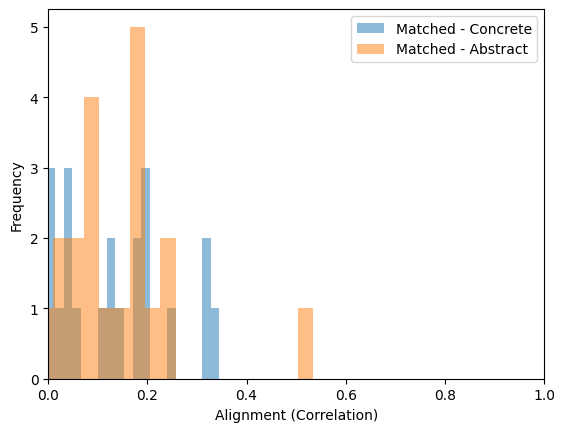

In [47]:
plt.hist(alignment_con, bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(alignment_abs, bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Alignment (Correlation)')
plt.ylabel('Frequency')
plt.xlim(0, 1)
# plt.title('CLIP\nDistribution of Matching Scores')
plt.legend()
plt.show()

In [32]:
t_stat, p_value = ttest_rel(alignment_con, alignment_abs)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 0.1459194106473123, P-value: 0.8854457077347055


### By item

In [10]:
imgs = df_clip['image_id'].unique()
img_num = len(imgs)

score_mean_con = np.zeros(img_num)
score_mean_abs = np.zeros(img_num)
score_clip_con = np.zeros(img_num)
score_clip_abs = np.zeros(img_num)

for i, img in enumerate(imgs):
    df_img = df_human[(df_human['match'] == 'matched') & (df_human['image_id']==img)]
    score_mean_con[i] = df_img[df_img['condition'] == 'con']['answer_normalized'].mean()
    score_mean_abs[i] = df_img[df_img['condition'] == 'abs']['answer_normalized'].mean()

    score_clip_con[i] = df_clip[df_clip['image_id'] == img]['con_matching_score_normalized'].values[0]
    score_clip_abs[i] = df_clip[df_clip['image_id'] == img]['abs_matching_score_normalized'].values[0]

In [11]:
from scipy.stats import pearsonr
from statsmodels.stats.anova import AnovaRM
import pandas as pd

# Prepare the data for ANOVA
# 'Condition' (Concrete vs Abstract) is a within-subject factor, not a between-subject factor.
data = pd.DataFrame({
    'Image': list(range(1, img_num + 1)) * 2,
    'Condition': ['Concrete'] * img_num + ['Abstract'] * img_num,
    'Human': np.concatenate([score_mean_con, score_mean_abs]),
    'CLIP': np.concatenate([score_clip_con, score_clip_abs])
})

# Melt the data for repeated measures ANOVA
data_melted = pd.melt(data, id_vars=['Image', 'Condition'], value_vars=['Human', 'CLIP'], 
                      var_name='Model', value_name='Score')

# anova_results_rm = AnovaRM(data_melted, 'Score', 'Image', 
#                            within=['Model'], 
#                            between=['Condition']).fit()

# print(anova_results_rm)

In [12]:
data.to_csv("anova_normalized.csv")

maybe also test human accuracy on matched vs mismatched?